# bioseqkit demo

This notebook demonstrates the core features of **bioseqkit** on a real
sequence. It tries to download the human mitochondrion (`chrM`) from NCBI; if
there is no network access it falls back to a synthetic multi-sequence dataset
for meaningful visualisations.

## 1. Load data (NCBI with local fallback)

In [1]:
import io
import random

import bioseqkit as bsk

records = []
try:
    from bioseqkit.entrez import efetch_fasta

    fasta_text = efetch_fasta("NC_012920.1", email="you@example.com")
    records = list(bsk.parse_fasta(io.StringIO(fasta_text)))
    print("Downloaded from NCBI:", records[0].id, records[0].description)
except Exception as exc:
    random.seed(0)
    fake = io.StringIO()
    for i in range(12):
        seq = "".join(random.choice("ACGT") for _ in range(random.randint(300, 2500)))
        fake.write(f">seq{i}\n{seq}\n")
    fake.seek(0)
    records = list(bsk.parse_fasta(fake))
    print("Using synthetic data (no network):", exc)

for r in records:
    print(r.id, len(r), r.description)

Downloaded from NCBI: NC_012920.1 Homo sapiens mitochondrion, complete genome
NC_012920.1 16569 Homo sapiens mitochondrion, complete genome


## 2. Basic statistics

In [2]:
import json

stats = bsk.sequence_stats(r.sequence for r in records)
print(json.dumps(stats.as_dict(), indent=2))

{
  "n_seqs": 1,
  "total_length": 16569,
  "min_length": 16569,
  "max_length": 16569,
  "mean_length": 16569.0,
  "n50": 16569,
  "gc_content": 0.443599,
  "n_ratio": 6e-05,
  "base_counts": {
    "G": 2169,
    "A": 5124,
    "T": 4094,
    "C": 5181,
    "N": 1
  }
}


## 3. GC content & length distribution

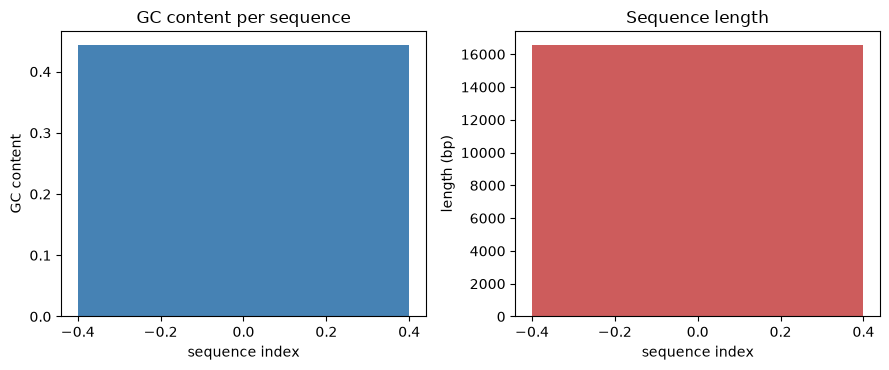

In [3]:
import matplotlib.pyplot as plt

gc = [bsk.gc_content(r.sequence) for r in records]
lengths = [len(r) for r in records]

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
axes[0].bar(range(len(gc)), gc, color='steelblue')
axes[0].set_xlabel('sequence index')
axes[0].set_ylabel('GC content')
axes[0].set_title('GC content per sequence')
axes[1].bar(range(len(lengths)), lengths, color='indianred')
axes[1].set_xlabel('sequence index')
axes[1].set_ylabel('length (bp)')
axes[1].set_title('Sequence length')
plt.tight_layout()
plt.show()

## 4. k-mer spectrum

Top-10 canonical 4-mers:
  CCTA	270
  AAAA	245
  CCCC	239
  ATTA	237
  AATA	233
  ACCC	217
  ACTA	214
  AGGG	212
  TAAA	212
  AACC	205


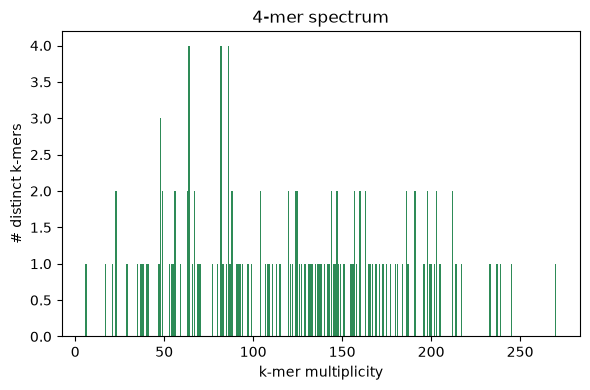

In [4]:
from collections import Counter

k = 4
counts = Counter()
for r in records:
    counts += bsk.count_kmers(r.sequence, k, canonical=True)

print('Top-10 canonical %d-mers:' % k)
for kmer, c in bsk.top_kmers(counts, 10):
    print(f'  {kmer}\t{c}')

spectrum = Counter(counts.values())
xs = sorted(spectrum)
plt.figure(figsize=(6, 4))
plt.bar(xs, [spectrum[x] for x in xs], color='seagreen')
plt.xlabel('k-mer multiplicity')
plt.ylabel('# distinct k-mers')
plt.title(f'{k}-mer spectrum')
plt.tight_layout()
plt.show()

## 5. Six-frame translation

In [5]:
seq = records[0].sequence
for frame in bsk.six_frame_translation(seq):
    print(frame.name, frame.protein[:60])

+1 DHRSITLLTTHGSSPCIWYFRLGGMHAIALRDAGAGAPYVAVSVFDSCLILLFIAPTFNI
+2 ITGLSPY*PLTGALHAFGIFVWGVCTR*HCETLEPEHPMSQYLSLIPASSYYLSHLRSIL
+3 SQVYHPINHSRELSMHLVFSSGGYARDSIARRWSRSTLCRSICL*FLPHPIIYRTYVQYY
-1 HRDVLFKGNVWAI*AL*P*SRNQMSDTVHFSYPQVLWARSEESSTLVRDIDFTEDGGQGT
-2 IVMSYLRGTCGLFRLYDPEVGTRCRIQFTLATPKCYGPGARRVALLCGILISRRMVVKGP
-3 S*CLI*GERVGYLGFMTLK*EPDVGYSSL*LPPSVMGPERGE*HSCAGY*FHGGWWSRDP


## 6. Minimizer distribution

6005 minimizers selected from 16569 bp


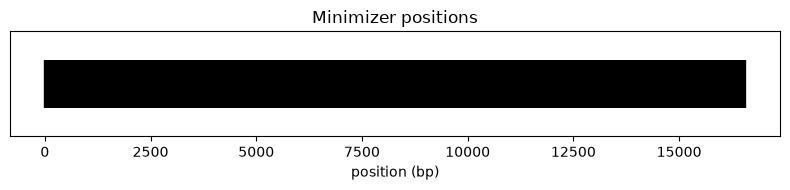

In [6]:
mins = bsk.minimizers(records[0].sequence, k=8, w=5)
positions = [p for p, _ in mins]
print(f'{len(mins)} minimizers selected from {len(records[0])} bp')
plt.figure(figsize=(8, 2))
plt.eventplot(positions, colors='black')
plt.xlabel('position (bp)')
plt.title('Minimizer positions')
plt.yticks([])
plt.tight_layout()
plt.show()

## 7. Random access with the FAI-like index

In [7]:
import tempfile
from pathlib import Path

fa = Path(tempfile.mkdtemp()) / "test.fa"
bsk.write_fasta(records, open(str(fa), "w"))

from bioseqkit.index import build_faidx

idx = build_faidx(str(fa))
name = idx.names()[0]
print('Index records:', idx.names())
print('Fetch', name, '1-20:', idx.fetch(name, 1, 20))

Index records: ['NC_012920.1']
Fetch NC_012920.1 1-20: GATCACAGGTCTATCACCCT


## 8. Multithreaded k-mer benchmark

In [8]:
import time

big = records[0].sequence * 2000
print(f'sequence length: {len(big):,} bp')

t0 = time.perf_counter()
c1 = bsk.count_kmers(big, 8, canonical=True)
t1 = time.perf_counter()
c4 = bsk.count_kmers_parallel([big], 8, canonical=True, workers=4)
t2 = time.perf_counter()
print(f'serial:   {t1 - t0:.3f}s')
print(f'parallel: {t2 - t1:.3f}s  (identical result: {c1 == c4})')

sequence length: 33,138,000 bp
serial:   32.018s
parallel: 8.426s  (identical result: True)
